In [73]:
#IMPORT REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [74]:
#LOAD DATASET
df = pd.read_csv(r"C:\Users\sayam\OneDrive\Documents\RETAIL_DATA\retail_sales_dataset.csv")
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,24-11-2023,CUST001,Male,34,Beauty,3,50,150
1,2,27-02-2023,CUST002,Female,26,Clothing,2,500,1000
2,3,13-01-2023,CUST003,Male,50,Electronics,1,30,30
3,4,21-05-2023,CUST004,Male,37,Clothing,1,500,500
4,5,06-05-2023,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,16-05-2023,CUST996,Male,62,Clothing,1,50,50
996,997,17-11-2023,CUST997,Male,52,Beauty,3,30,90
997,998,29-10-2023,CUST998,Female,23,Beauty,4,25,100
998,999,05-12-2023,CUST999,Female,36,Electronics,3,50,150


In [122]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount,quarter
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000,2.525000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000,1.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000,2.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000,2.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000,4.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000,4.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632,1.119208


In [113]:
df.isnull().sum() #checking missing values

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
month               0
quarter             0
dtype: int64

In [75]:
df.info() # INSPECTION

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [76]:
# finding mean, median, mode, std.dev
col=['Age','Quantity','Price per Unit','Total Amount']
stacs=pd.DataFrame({'Mean':df[col].mean(),
                    'Median':df[col].median(),
                    'Mode':df[col].mode().iloc[0],
                    'Standard deviation':df[col].std()})
stacs

,Mean,Median,Mode,Standard deviation
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [89]:
# extract date
df['Date']=pd.to_datetime(df['Date'],format='%d-%m-%Y')

In [78]:
#convert month and quarter from date
df['month']=df['Date'].dt.month_name()
df['quarter']=df['Date'].dt.quarter
df[['Date','month','quarter']].head()

,Date,month,quarter
0,2023-11-24,November,4
1,2023-02-27,February,1
2,2023-01-13,January,1
3,2023-05-21,May,2
4,2023-05-06,May,2


In [85]:
#months in order
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]
df['month']= pd.Categorical(
    df['month'],
    categories=month_order,
    ordered=True
)
#grp amt by month
df_group=df.groupby(['month'],observed=False)['Total Amount'].sum().reset_index()
#arrange rows according to month
df_sort=df_group.sort_values('month')

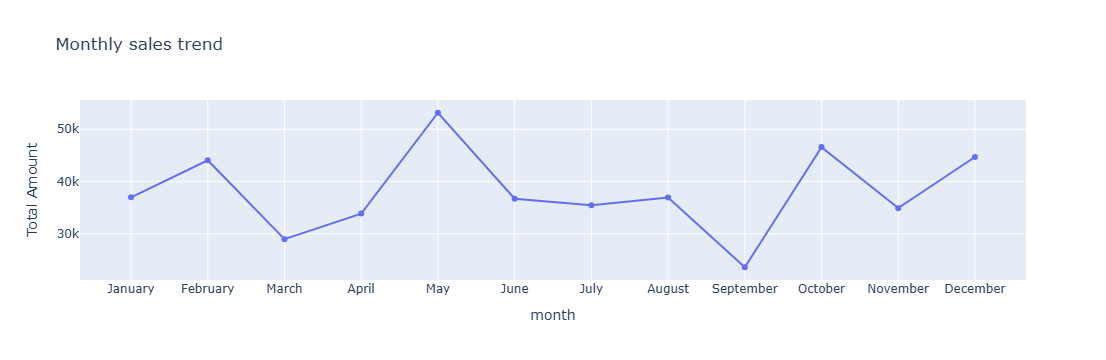

In [86]:
# VISUALIZE MONTHLY SALES USING PLOTY
fig=px.line(df_sort,x='month',y='Total Amount',title='Monthly sales trend',markers=True)
fig.show()

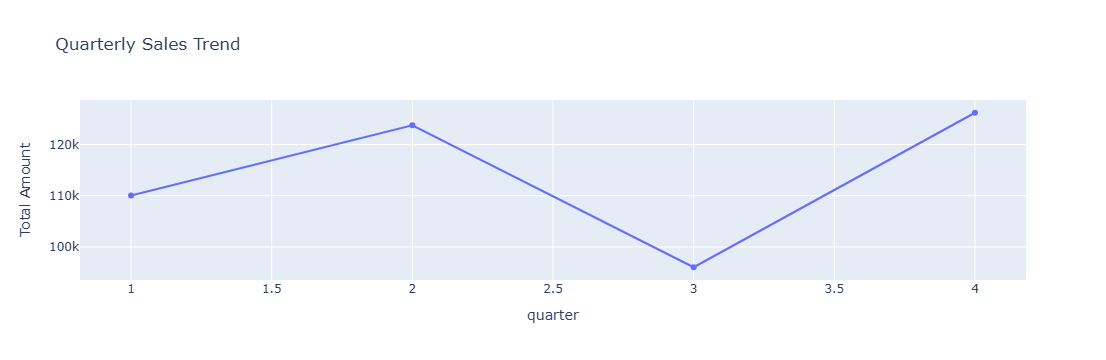

In [87]:
#grp amt by quarter
df_time1=df.groupby(['quarter'])['Total Amount'].sum().reset_index()
#VISUALIZE QUARTELY SALES TREND USING PLOTY
fig=px.line(df_time1,x='quarter',y='Total Amount',title='Quarterly Sales Trend',markers=True)
fig.show()

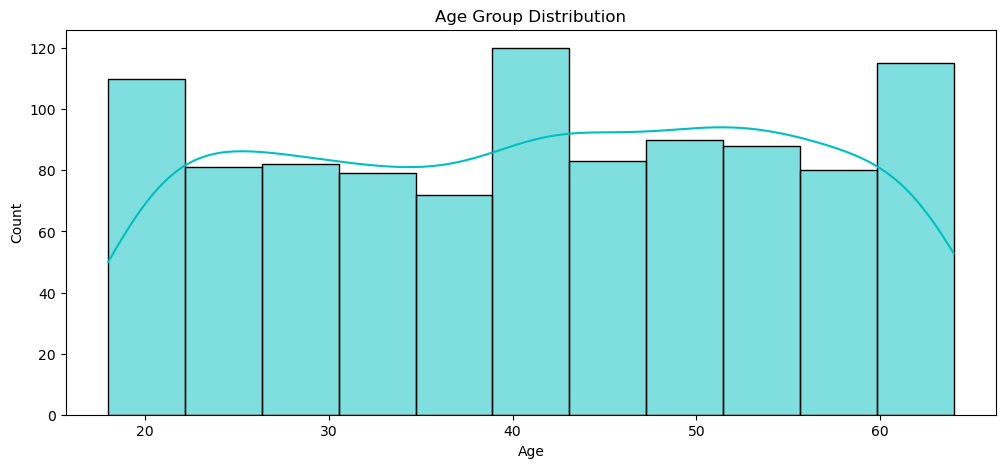

In [128]:
#DEMOGRAPHICS ANALYSIS:AGE GROUP 
plt.figure(figsize=(12,5))
sns.histplot(df,x=df['Age'].sort_values(),kde=True,color='c')
plt.title('Age Group Distribution')
plt.show()

In [99]:
#Demographics analysis: Gender Distribution
category_count=df['Gender'].value_counts().reset_index()
category_count.columns=['Gender','Count']
category_count

,Gender,Count
0,Female,510
1,Male,490


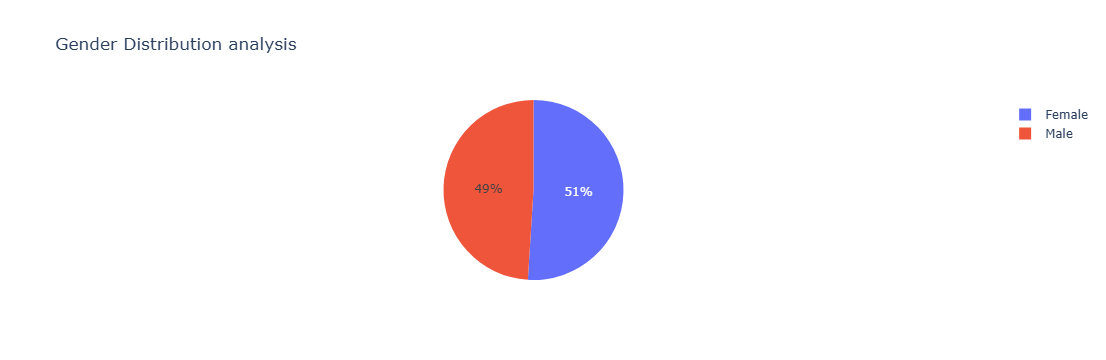

In [102]:
fig=px.pie(category_count,names='Gender',values='Count',title='Gender Distribution analysis')
fig.show()

In [116]:
# analysis of revenue by gender and age grp
rev_genage=df.groupby(['Age','Gender'],observed=False)['Total Amount'].sum().reset_index()
rev_genage

,Age,Gender,Total Amount
0,18,Female,7940
1,18,Male,3275
2,19,Female,7335
3,19,Male,7535
4,20,Female,5175
...,...,...,...
89,62,Male,5060
90,63,Female,1205
91,63,Male,8045
92,64,Female,6325


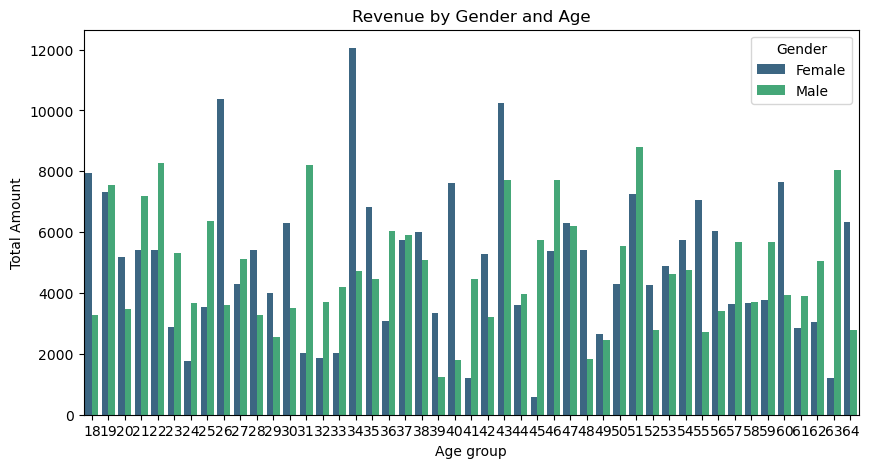

In [133]:
#visualization
plt.figure(figsize=(10,5))
sns.barplot(rev_genage,x='Age',y='Total Amount',hue='Gender',palette='viridis')
plt.title("Revenue by Gender and Age")
plt.xlabel("Age group")
plt.ylabel("Total Amount")
plt.show()

In [112]:
# Best selling product category
best_cat=df.groupby('Product Category')['Quantity'].sum().reset_index()
best_cat.sort_values('Quantity',ascending=False)

,Product Category,Quantity
1,Clothing,894
2,Electronics,849
0,Beauty,771


Text(0, 0.5, 'sales')

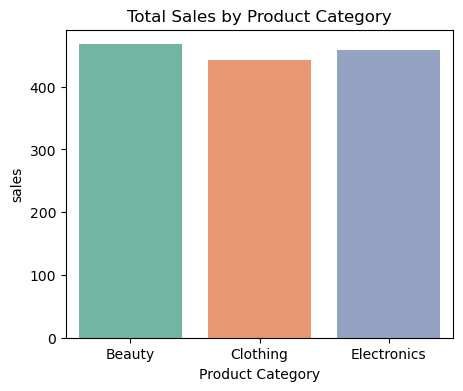

In [110]:
# VISUALIZATION: Product Category and Total Amount
plt.figure(figsize=(5,4))
plt.title("Total Sales by Product Category")
sns.barplot(data=df,x=df['Product Category'],y=df['Total Amount'],palette='Set2',hue='Product Category',legend=False,errorbar=None)
plt.ylabel("sales")

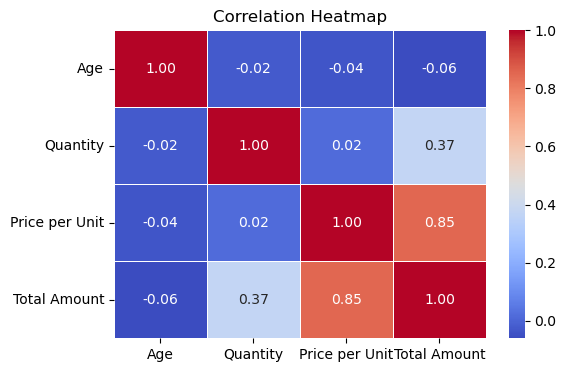

In [37]:
# HEATMAP:CORELATION MATRIX BETWEEN NUMERICAL VALUES
plt.figure(figsize=(6,4))
dataframe=pd.DataFrame(data=df,columns=['Age','Quantity','Price per Unit','Total Amount'])
matrix=dataframe.corr()
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

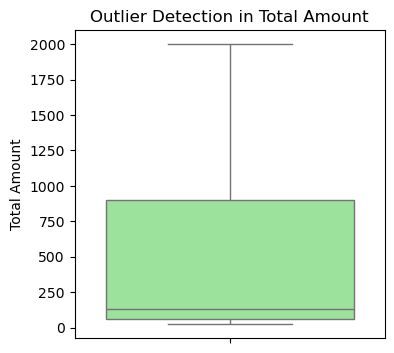

In [104]:
#OUTLIERS IN TOTAL AMOUNT
plt.figure(figsize=(4,4))
sns.boxplot(data=df['Total Amount'],color='lightgreen')
plt.title("Outlier Detection in Total Amount")
plt.show()

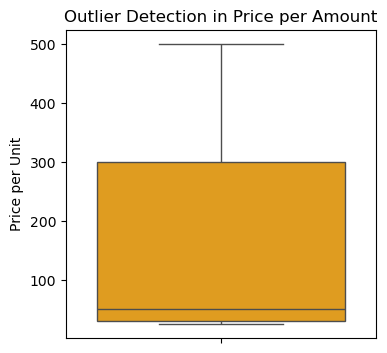

In [91]:
# OUTLIERS IN PRICE PER UNIT
plt.figure(figsize=(4,4))
sns.boxplot(data=df['Price per Unit'],color='orange')
plt.title("Outlier Detection in Price per Amount")
plt.show()